# Лабораторная работа 2. Градиентный спуск: классика

## Цель работы

Реализовать четыре метода градиентного спуска и сравнить их на квадратичных функциях и на сложных функциях Розенброка, Экли и Химмельблау. Для каждого метода смотрим число итераций и вызовов функции/градиента и строим траектории на линиях уровня.

## Описание методов

Все методы строят последовательность $x_{k} = x_{k-1} - \alpha_k\, g_{k-1}$, где $g = \nabla f$ - градиент, $\alpha_k$ - длина шага. Различаются только выбором $\alpha_k$:

- **Постоянный шаг** - $\alpha_k \equiv \alpha$ фиксировано (вызывается только градиент).
- **Армихо** - пробный шаг $\alpha_0 = 1$ делится на $q = 0.5$, пока не выполнится условие достаточного убывания $f(x - \alpha g) \le f(x) - c_1\,\alpha\,\|g\|^2$.
- **Сильные условия Вольфе** - к Армихо добавляется условие на производную $|\langle \nabla f(x - \alpha g),\, -g \rangle| \le c_2\,\|g\|^2$; реализуется поиском bracketing + zoom.
- **Наискорейший спуск** - шаг выбирается точно $\alpha_k = \arg\min_{\alpha \ge 0} f(x - \alpha g)$ (расширение интервала удвоением + золотое сечение).

Критерий остановки во всех методах: $\|\nabla f(x_k)\| \le \varepsilon$, плюс ограничение по числу итераций и проверка на расходимость.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

## Тестовые функции и их градиенты

In [2]:
"""Тестовые функции и их градиенты.

Каждая функция принимает точку p = [x, y] (numpy-массив) и возвращает число.
Градиент принимает p и возвращает numpy-массив [df/dx, df/dy].
"""

import numpy as np

def f_quad_good(p):
    x, y = p
    return x ** 2 + 2 * y ** 2

def grad_quad_good(p):
    x, y = p
    return np.array([2 * x, 4 * y])

def g_quad_bad(p):
    x, y = p
    return x ** 2 + 100 * y ** 2

def grad_quad_bad(p):
    x, y = p
    return np.array([2 * x, 200 * y])

def rosenbrock(p):
    x, y = p
    return (1 - x) ** 2 + 100 * (y - x ** 2) ** 2

def grad_rosenbrock(p):
    x, y = p
    dx = -2 * (1 - x) - 400 * x * (y - x ** 2)
    dy = 200 * (y - x ** 2)
    return np.array([dx, dy])

def ackley(p):
    x, y = p
    r = np.sqrt(0.5 * (x ** 2 + y ** 2))
    s = 0.5 * (np.cos(2 * np.pi * x) + np.cos(2 * np.pi * y))
    return -20 * np.exp(-0.2 * r) - np.exp(s) + 20 + np.e

def grad_ackley(p):
    x, y = p
    r = np.sqrt(0.5 * (x ** 2 + y ** 2))
    s = 0.5 * (np.cos(2 * np.pi * x) + np.cos(2 * np.pi * y))
    if r == 0:
        first_x = first_y = 0.0
    else:
        first_x = 2 * x * np.exp(-0.2 * r) / r
        first_y = 2 * y * np.exp(-0.2 * r) / r
    dx = first_x + np.pi * np.sin(2 * np.pi * x) * np.exp(s)
    dy = first_y + np.pi * np.sin(2 * np.pi * y) * np.exp(s)
    return np.array([dx, dy])

def himmelblau(p):
    x, y = p
    return (x ** 2 + y - 11) ** 2 + (x + y ** 2 - 7) ** 2

def grad_himmelblau(p):
    x, y = p
    a = x ** 2 + y - 11
    b = x + y ** 2 - 7
    dx = 4 * x * a + 2 * b
    dy = 2 * a + 4 * y * b
    return np.array([dx, dy])


## Методы градиентного спуска

In [3]:
"""Методы градиентного спуска из лекции 6.

Все методы используют одинаковый критерий остановки: ||grad f(x)|| <= eps
(в точке минимума градиент равен нулю). Дополнительно есть ограничение
по числу итераций и проверка на расходимость (если точка ушла слишком далеко).

Каждый метод принимает обертку-счетчик oracle, через которую считаются
вызовы функции и градиента, и возвращает словарь с результатами.
"""

import numpy as np

class Counter:
    """Обертка над функцией и градиентом, которая считает число вызовов."""

    def __init__(self, f, grad):
        self._f = f
        self._grad = grad
        self.nf = 0
        self.ng = 0

    def f(self, x):
        self.nf += 1
        return self._f(x)

    def grad(self, x):
        self.ng += 1
        return self._grad(x)

def _result(x, traj, iters, converged, oracle):
    return {
        "x": x,
        "traj": np.array(traj),
        "iters": iters,
        "converged": converged,
        "nf": oracle.nf,
        "ng": oracle.ng,
    }

def gd_const(oracle, x0, alpha, eps, max_iter=100000):
    x = np.array(x0, dtype=float)
    traj = [x.copy()]
    converged = False
    it = 0
    while it < max_iter:
        g = oracle.grad(x)
        if np.linalg.norm(g) <= eps:
            converged = True
            break
        x = x - alpha * g
        if np.linalg.norm(x) > 1e6:   # точка улетела слишком далеко - метод разошелся
            break
        traj.append(x.copy())
        it += 1
    return _result(x, traj, it, converged, oracle)

def gd_armijo(oracle, x0, eps, c1=1e-4, q=0.5, alpha0=1.0, max_iter=100000):
    x = np.array(x0, dtype=float)
    traj = [x.copy()]
    converged = False
    it = 0
    while it < max_iter:
        g = oracle.grad(x)
        if np.linalg.norm(g) <= eps:
            converged = True
            break
        fx = oracle.f(x)
        gg = g @ g
        alpha = alpha0
        while oracle.f(x - alpha * g) > fx - c1 * alpha * gg:
            alpha *= q
            if alpha < 1e-20:
                break
        x = x - alpha * g
        if np.linalg.norm(x) > 1e6:   # точка улетела слишком далеко - метод разошелся
            break
        traj.append(x.copy())
        it += 1
    return _result(x, traj, it, converged, oracle)

def _wolfe_step(oracle, x, g, fx, c1, c2, a_max=10.0):
    """Поиск шага вдоль направления p = -g, удовлетворяющего сильным условиям Вольфе.

    phi(a)  = f(x - a g),  phi'(a) = <grad f(x - a g), -g>.
    phi(0) = fx, phi'(0) = -||g||^2 < 0.
    Возвращает длину шага a.
    """
    dphi0 = -(g @ g)

    def phi(a):
        return oracle.f(x - a * g)

    def dphi(a):
        return oracle.grad(x - a * g) @ (-g)

    def zoom(a_lo, a_hi, phi_lo):
        for _ in range(50):
            a = 0.5 * (a_lo + a_hi)
            phi_a = phi(a)
            if phi_a > fx + c1 * a * dphi0 or phi_a >= phi_lo:
                a_hi = a
            else:
                if abs(dphi(a)) <= -c2 * dphi0:
                    return a
                if dphi(a) * (a_hi - a_lo) >= 0:
                    a_hi = a_lo
                a_lo, phi_lo = a, phi_a
        return 0.5 * (a_lo + a_hi)

    a_prev, phi_prev = 0.0, fx
    a = 1.0
    for i in range(50):
        phi_a = phi(a)
        if phi_a > fx + c1 * a * dphi0 or (i > 0 and phi_a >= phi_prev):
            return zoom(a_prev, a, phi_prev)
        if abs(dphi(a)) <= -c2 * dphi0:
            return a
        if dphi(a) >= 0:
            return zoom(a, a_prev, phi_a)
        a_prev, phi_prev = a, phi_a
        a = min(2 * a, a_max)
    return a

def gd_wolfe(oracle, x0, eps, c1=1e-4, c2=0.9, max_iter=100000):
    x = np.array(x0, dtype=float)
    traj = [x.copy()]
    converged = False
    it = 0
    while it < max_iter:
        g = oracle.grad(x)
        if np.linalg.norm(g) <= eps:
            converged = True
            break
        fx = oracle.f(x)
        alpha = _wolfe_step(oracle, x, g, fx, c1, c2)
        x = x - alpha * g
        if np.linalg.norm(x) > 1e6:   # точка улетела слишком далеко - метод разошелся
            break
        traj.append(x.copy())
        it += 1
    return _result(x, traj, it, converged, oracle)

def _bracket_min(phi, step=1.0):
    """Расширяем интервал удвоением, пока функция убывает (схема из лекции 6).

    Возвращает интервал [a, c], внутри которого лежит минимум phi(a), a >= 0.
    """
    a, fa = 0.0, phi(0.0)
    b, fb = step, phi(step)
    if fb > fa:
        return a, b
    while True:
        c = 2 * b
        fc = phi(c)
        if fc > fb:
            return a, c
        a, fa = b, fb
        b, fb = c, fc

def _golden(phi, a, b, tol=1e-8):
    """Метод золотого сечения из лекции 2 для минимизации phi на [a, b]."""
    inv_phi = (np.sqrt(5) - 1) / 2
    c = b - inv_phi * (b - a)
    d = a + inv_phi * (b - a)
    fc, fd = phi(c), phi(d)
    while (b - a) > tol:
        if fc < fd:
            b, d, fd = d, c, fc
            c = b - inv_phi * (b - a)
            fc = phi(c)
        else:
            a, c, fc = c, d, fd
            d = a + inv_phi * (b - a)
            fd = phi(d)
    return 0.5 * (a + b)

def gd_steepest(oracle, x0, eps, max_iter=100000):
    x = np.array(x0, dtype=float)
    traj = [x.copy()]
    converged = False
    it = 0
    while it < max_iter:
        g = oracle.grad(x)
        if np.linalg.norm(g) <= eps:
            converged = True
            break

        def phi(a):
            return oracle.f(x - a * g)

        a, b = _bracket_min(phi)
        alpha = _golden(phi, a, b)
        x = x - alpha * g
        if np.linalg.norm(x) > 1e6:   # точка улетела слишком далеко - метод разошелся
            break
        traj.append(x.copy())
        it += 1
    return _result(x, traj, it, converged, oracle)


## Вспомогательные функции

In [4]:
EPS = 1e-8

def run(method, f, grad, x0, **kw):
    oracle = Counter(f, grad)
    return method(oracle, x0, **kw)

def fnum(v, d=4):
    return f"{v:.{d}g}"

def print_table(title, headers, rows):
    print(title)
    cols = list(zip(*([headers] + rows)))
    widths = [max(len(str(c)) for c in col) for col in cols]
    def fmt(r):
        return " | ".join(str(c).ljust(widths[i]) for i, c in enumerate(r))
    print(fmt(headers))
    print("-+-".join("-" * w for w in widths))
    for r in rows:
        print(fmt(r))

PLOT_CFG = {
    "f": ((-6, 6), (-6, 6), np.linspace(2, 80, 12), [(0, 0)]),
    "g": ((-6, 6), (-6, 6), np.logspace(0, 3.4, 14), [(0, 0)]),
    "rosen": ((-2, 2), (-1, 3), np.logspace(0, 3.5, 18), [(1, 1)]),
    "ackley": ((-5, 5), (-5, 5), np.linspace(0.5, 14, 14), [(0, 0)]),
    "himmel": ((-5, 5), (-5, 5), np.logspace(0, 2.8, 18),
               [(3, 2), (-2.805, 3.131), (-3.779, -3.283), (3.584, -1.848)]),
}

STARTS = {
    "rosen": [(-1.2, 1.0), (0.0, 2.0), (2.0, 2.0)],
    "ackley": [(2.0, 2.0), (-3.0, 3.0), (1.0, -2.0)],
    "himmel": [(0.0, 0.0), (-2.0, 3.0), (3.0, -2.0), (-4.0, -4.0)],
}

def contour(ax, f, xlim, ylim, levels, n=400):
    xs = np.linspace(xlim[0], xlim[1], n)
    ys = np.linspace(ylim[0], ylim[1], n)
    X, Y = np.meshgrid(xs, ys)
    Z = f((X, Y))
    ax.contour(X, Y, Z, levels=levels, cmap="viridis", linewidths=0.7)
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_xlabel("x"); ax.set_ylabel("y")

def show_traj(title, f, key, runs):
    xlim, ylim, levels, minpts = PLOT_CFG[key]
    fig, ax = plt.subplots(figsize=(6, 5))
    contour(ax, f, xlim, ylim, levels)
    for label, traj in runs:
        ax.plot(traj[:, 0], traj[:, 1], "-o", markersize=2, linewidth=1, label=label)
    ax.plot([p[0] for p in minpts], [p[1] for p in minpts], "r*", markersize=12, label="минимум")
    ax.set_title(title); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

def show_metrics(title, eps_list, series):
    x = [-int(round(np.log10(e))) for e in eps_list]
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    names = ["число итераций", "вызовы функции", "вызовы градиента"]
    for j, name in enumerate(names):
        for label, it, nf, ng in series:
            axes[j].plot(x, [it, nf, ng][j], "-o", label=label)
        axes[j].set_xlabel("точность 10^-k (k)"); axes[j].set_ylabel(name)
        axes[j].set_yscale("log"); axes[j].grid(True, which="both", linewidth=0.3)
        axes[j].legend(fontsize=8)
    fig.suptitle(title); plt.tight_layout(); plt.show()

## Пункт 1

Постоянный шаг на квадратичных функциях. Перебираем разные шаги `α` и смотрим, при каком из них метод сходится за меньше всего итераций (точность `ε=1e-8`). Лучшие шаги запоминаем для пункта 3.

Функция f  (хорошо обусл., k=2)
alpha | итераций | результат
------+----------+----------
0.05  | 197      | сошелся  
0.1   | 93       | сошелся  
0.15  | 59       | сошелся  
0.2   | 41       | сошелся  
0.25  | 30       | сошелся  
0.3   | 23       | сошелся  
0.333 | 20       | сошелся  
0.35  | 24       | сошелся  
0.4   | 42       | сошелся  
0.45  | 96       | сошелся  
0.49  | 525      | сошелся  
  -> наименьшее число итераций при alpha = 0.333



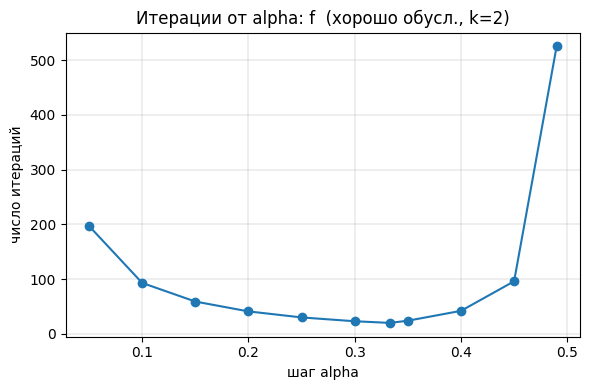

Функция g  (плохо обусл., k=100)
alpha  | итераций | результат
-------+----------+----------
0.001  | 10352    | сошелся  
0.002  | 5171     | сошелся  
0.003  | 3444     | сошелся  
0.004  | 2581     | сошелся  
0.005  | 2062     | сошелся  
0.006  | 1717     | сошелся  
0.007  | 1470     | сошелся  
0.008  | 1285     | сошелся  
0.009  | 1141     | сошелся  
0.0095 | 1081     | сошелся  
0.0099 | 1254     | сошелся  
  -> наименьшее число итераций при alpha = 0.0095



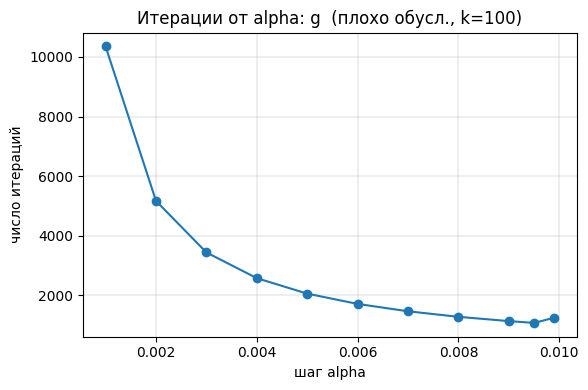

In [5]:
best = {}
cases = [
    ("f  (хорошо обусл., k=2)", "f", f_quad_good, grad_quad_good, (5., 5.),
     [0.05, 0.1, 0.15, 0.2, 0.25, 0.30, 0.333, 0.35, 0.40, 0.45, 0.49]),
    ("g  (плохо обусл., k=100)", "g", g_quad_bad, grad_quad_bad, (5., 5.),
     [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009, 0.0095, 0.0099]),
]
for name, key, f, grad, x0, alphas in cases:
    rows = []; conv = []
    for a in alphas:
        r = run(gd_const, f, grad, x0, alpha=a, eps=EPS)
        rows.append([fnum(a), r["iters"] if r["converged"] else "-",
                     "сошелся" if r["converged"] else "разошелся"])
        if r["converged"]:
            conv.append((a, r["iters"]))
    best_a = min(conv, key=lambda t: t[1])[0]; best[key] = best_a
    print_table(f"Функция {name}", ["alpha", "итераций", "результат"], rows)
    print(f"  -> наименьшее число итераций при alpha = {fnum(best_a)}\n")
    aa = [a for a, _ in conv]; ii = [it for _, it in conv]
    plt.figure(figsize=(6, 4)); plt.plot(aa, ii, "-o")
    plt.xlabel("шаг alpha"); plt.ylabel("число итераций")
    plt.title(f"Итерации от alpha: {name}"); plt.grid(True, linewidth=0.3)
    plt.tight_layout(); plt.show()

## Пункт 2

Постоянный шаг на сложных функциях при трех шагах `0.1, 0.01, 0.001` (ε=1e-8).

In [6]:
cases = [("Розенброка", rosenbrock, grad_rosenbrock, (-1.5, 1.5)),
         ("Экли", ackley, grad_ackley, (2., 2.)),
         ("Химмельблау", himmelblau, grad_himmelblau, (0., 0.))]
for name, f, grad, x0 in cases:
    rows = []
    for a in [0.1, 0.01, 0.001]:
        r = run(gd_const, f, grad, x0, alpha=a, eps=EPS)
        xf = r["x"]
        rows.append([fnum(a), r["iters"], "сошелся" if r["converged"] else "не сошелся",
                     f"({fnum(xf[0])}, {fnum(xf[1])})", fnum(f(xf))])
    print_table(f"Функция {name}, старт {x0}",
                ["alpha", "итераций", "результат", "конечная точка", "f(x)"], rows)
    print()

Функция Розенброка, старт (-1.5, 1.5)
alpha | итераций | результат  | конечная точка          | f(x)     
------+----------+------------+-------------------------+----------
0.1   | 1        | не сошелся | (-3.378e+06, 3.841e+04) | 1.303e+28
0.01  | 2        | не сошелся | (1.608e+06, 1.09e+04)   | 6.693e+26
0.001 | 43914    | сошелся    | (1, 1)                  | 1.252e-16



Функция Экли, старт (2.0, 2.0)
alpha | итераций | результат  | конечная точка     | f(x)  
------+----------+------------+--------------------+-------
0.1   | 100000   | не сошелся | (0.07391, 0.07391) | 0.5667
0.01  | 27       | сошелся    | (1.974, 1.974)     | 6.56  
0.001 | 366      | сошелся    | (1.974, 1.974)     | 6.56  

Функция Химмельблау, старт (0.0, 0.0)
alpha | итераций | результат  | конечная точка          | f(x)     
------+----------+------------+-------------------------+----------
0.1   | 4        | не сошелся | (-2.07e+13, -1.793e+11) | 1.835e+53
0.01  | 77       | сошелся    | (3, 2)                  | 1.939e-18
0.001 | 849      | сошелся    | (3, 2)                  | 1.887e-18



## Пункт 3

Линии уровня с траекториями постоянного шага: квадратичные - с лучшим шагом из пункта 1, сложные - с тремя шагами.

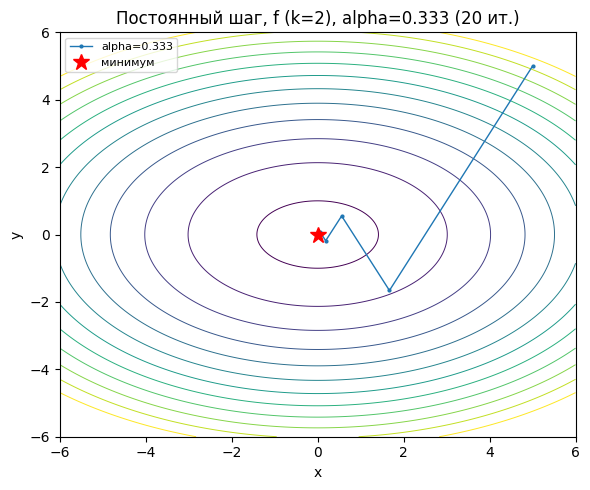

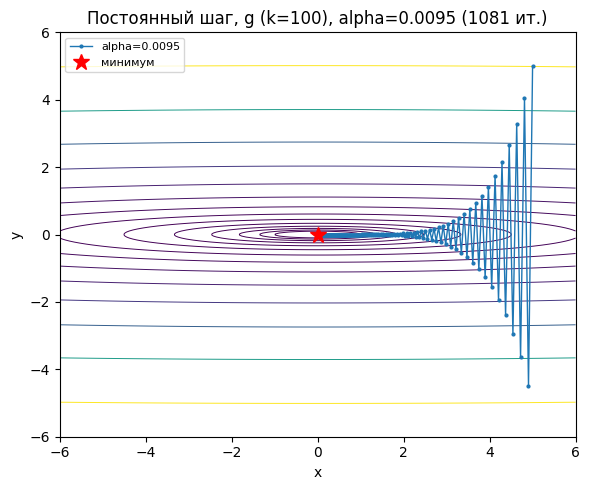

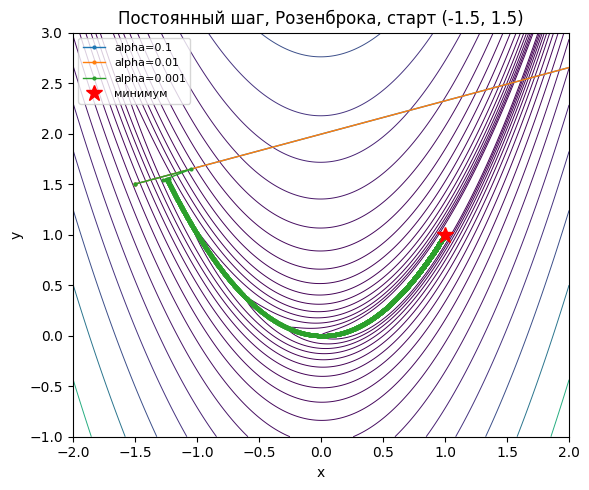

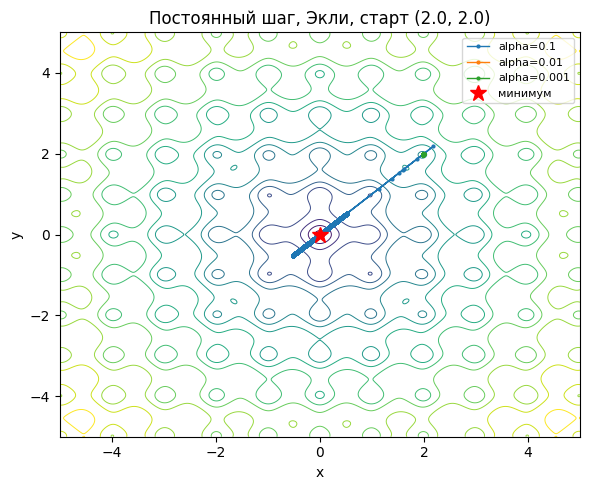

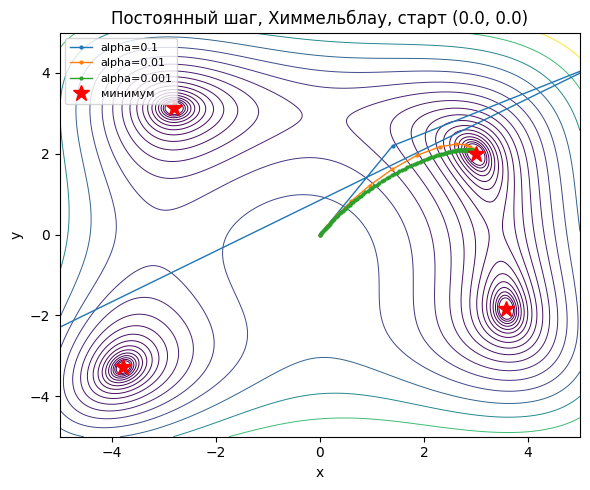

In [7]:
for key, name, f, grad, x0 in [
    ("f", "f (k=2)", f_quad_good, grad_quad_good, (5., 5.)),
    ("g", "g (k=100)", g_quad_bad, grad_quad_bad, (5., 5.))]:
    a = best[key]
    r = run(gd_const, f, grad, x0, alpha=a, eps=EPS)
    show_traj(f"Постоянный шаг, {name}, alpha={fnum(a)} ({r['iters']} ит.)",
              f, key, [(f"alpha={fnum(a)}", r["traj"])])

for key, name, f, grad, x0 in [
    ("rosen", "Розенброка", rosenbrock, grad_rosenbrock, (-1.5, 1.5)),
    ("ackley", "Экли", ackley, grad_ackley, (2., 2.)),
    ("himmel", "Химмельблау", himmelblau, grad_himmelblau, (0., 0.))]:
    runs = []
    for a in [0.1, 0.01, 0.001]:
        r = run(gd_const, f, grad, x0, alpha=a, eps=EPS)
        runs.append((f"alpha={a}", r["traj"]))
    show_traj(f"Постоянный шаг, {name}, старт {x0}", f, key, runs)

## Пункт 4

Дробление шага (Армихо и Вольфе) на квадратичных функциях. Для точностей от `1e-1` до `1e-8` смотрим число итераций и вызовов функции/градиента; в конце - траектории при `ε=1e-6`.

f (k=2), метод Армихо
eps    | итераций | вызовы f | вызовы grad
-------+----------+----------+------------
0.1    | 2        | 7        | 3          
0.01   | 2        | 7        | 3          
0.001  | 2        | 7        | 3          
0.0001 | 2        | 7        | 3          
1e-05  | 2        | 7        | 3          
1e-06  | 2        | 7        | 3          
1e-07  | 2        | 7        | 3          
1e-08  | 2        | 7        | 3          

f (k=2), метод Вольфе
eps    | итераций | вызовы f | вызовы grad
-------+----------+----------+------------
0.1    | 2        | 7        | 5          
0.01   | 2        | 7        | 5          
0.001  | 2        | 7        | 5          
0.0001 | 2        | 7        | 5          
1e-05  | 2        | 7        | 5          
1e-06  | 2        | 7        | 5          
1e-07  | 2        | 7        | 5          
1e-08  | 2        | 7        | 5          



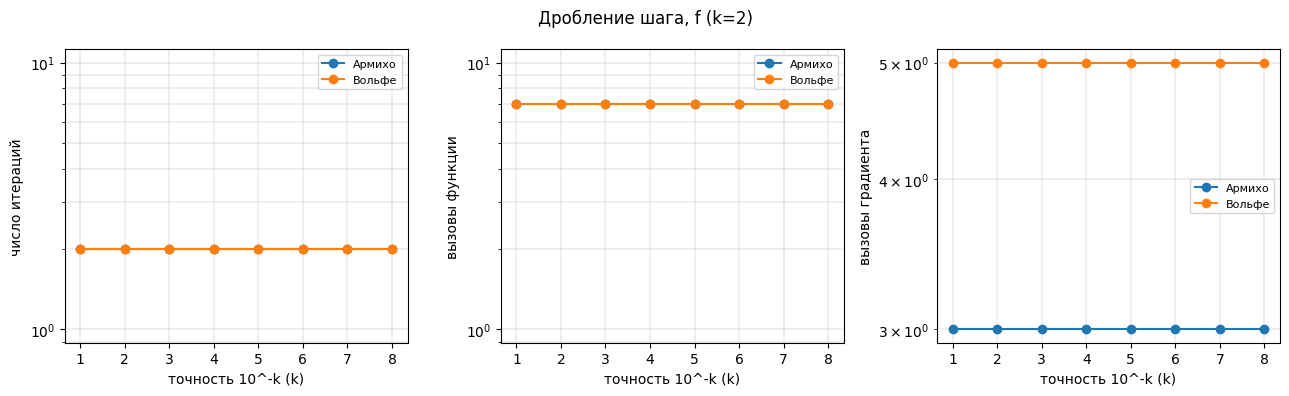

g (k=100), метод Армихо
eps    | итераций | вызовы f | вызовы grad
-------+----------+----------+------------
0.1    | 225      | 1935     | 226        
0.01   | 326      | 2802     | 327        
0.001  | 429      | 3686     | 430        
0.0001 | 530      | 4553     | 531        
1e-05  | 636      | 5463     | 637        
1e-06  | 737      | 6330     | 738        
1e-07  | 840      | 7214     | 841        
1e-08  | 946      | 8124     | 947        

g (k=100), метод Вольфе
eps    | итераций | вызовы f | вызовы grad
-------+----------+----------+------------
0.1    | 225      | 1935     | 471        
0.01   | 326      | 2802     | 687        
0.001  | 427      | 3669     | 899        
0.0001 | 528      | 4536     | 1109       
1e-05  | 629      | 5403     | 1321       
1e-06  | 737      | 6330     | 1549       
1e-07  | 838      | 7197     | 1765       
1e-08  | 939      | 8064     | 1977       



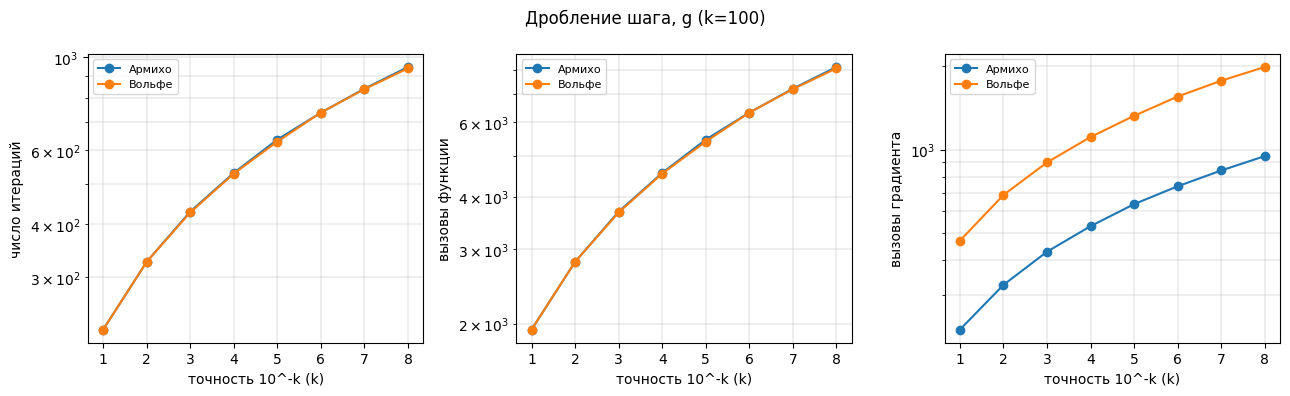

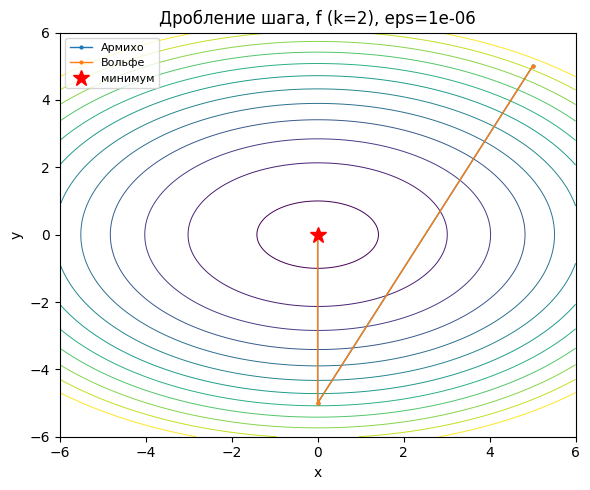

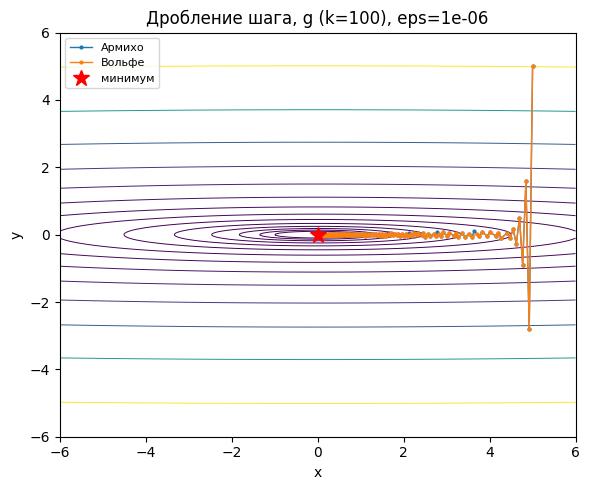

In [8]:
eps_list = [10.0 ** (-k) for k in range(1, 9)]
methods = [("Армихо", gd_armijo), ("Вольфе", gd_wolfe)]
for key, name, f, grad, x0 in [
    ("f", "f (k=2)", f_quad_good, grad_quad_good, (5., 5.)),
    ("g", "g (k=100)", g_quad_bad, grad_quad_bad, (5., 5.))]:
    series = []
    for mname, method in methods:
        rows = []; its = []; nfs = []; ngs = []
        for e in eps_list:
            r = run(method, f, grad, x0, eps=e)
            rows.append([fnum(e), r["iters"], r["nf"], r["ng"]])
            its.append(r["iters"]); nfs.append(r["nf"]); ngs.append(r["ng"])
        print_table(f"{name}, метод {mname}",
                    ["eps", "итераций", "вызовы f", "вызовы grad"], rows)
        print()
        series.append((mname, its, nfs, ngs))
    show_metrics(f"Дробление шага, {name}", eps_list, series)

e_show = 1e-6
for key, name, f, grad, x0 in [
    ("f", "f (k=2)", f_quad_good, grad_quad_good, (5., 5.)),
    ("g", "g (k=100)", g_quad_bad, grad_quad_bad, (5., 5.))]:
    runs = []
    for mname, method in methods:
        r = run(method, f, grad, x0, eps=e_show)
        runs.append((mname, r["traj"]))
    show_traj(f"Дробление шага, {name}, eps={fnum(e_show)}", f, key, runs)

## Пункт 5

Дробление шага на сложных функциях из разных стартовых точек (ε=1e-8): число итераций, вызовов и траектории.

Розенброка, метод Армихо
старт       | сошелся | итераций | вызовы f | вызовы grad | найдено
------------+---------+----------+----------+-------------+--------
(-1.2, 1.0) | да      | 19435    | 212800   | 19436       | (1, 1) 
(0.0, 2.0)  | да      | 20514    | 223981   | 20515       | (1, 1) 
(2.0, 2.0)  | да      | 23340    | 258400   | 23341       | (1, 1) 



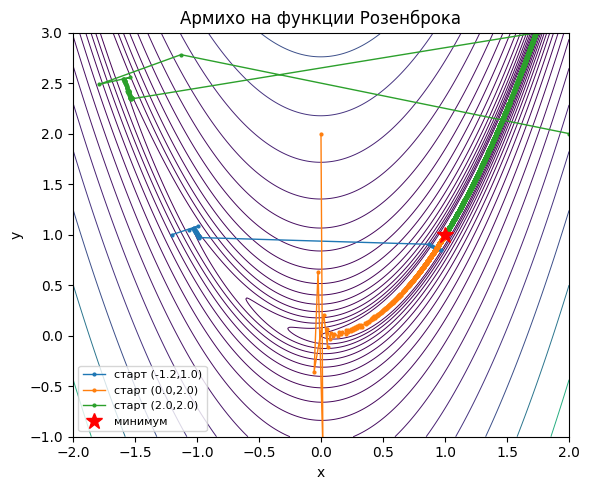

Розенброка, метод Вольфе
старт       | сошелся | итераций | вызовы f | вызовы grad | найдено
------------+---------+----------+----------+-------------+--------
(-1.2, 1.0) | да      | 16630    | 182203   | 34809       | (1, 1) 
(0.0, 2.0)  | да      | 20282    | 221649   | 42471       | (1, 1) 
(2.0, 2.0)  | да      | 18189    | 198980   | 38265       | (1, 1) 



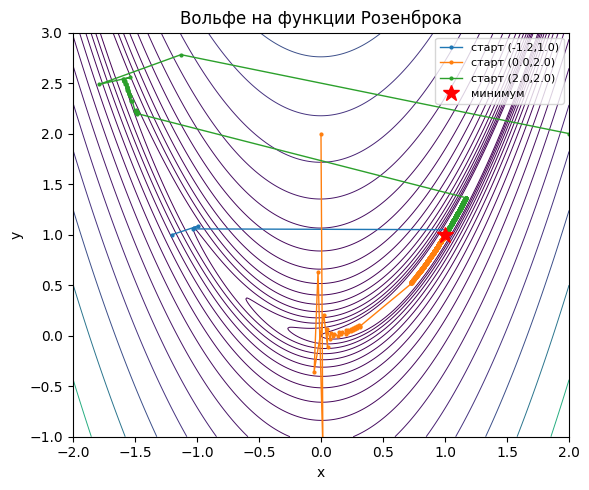

Экли, метод Армихо
старт       | сошелся | итераций | вызовы f | вызовы grad | найдено                 
------------+---------+----------+----------+-------------+-------------------------
(2.0, 2.0)  | нет     | 100000   | 6799173  | 100000      | (-1.354e-20, -1.354e-20)
(-3.0, 3.0) | нет     | 100000   | 3338633  | 100000      | (-1.974, 1.974)         
(1.0, -2.0) | нет     | 100000   | 6799123  | 100000      | (-5.768e-21, 7.817e-21) 



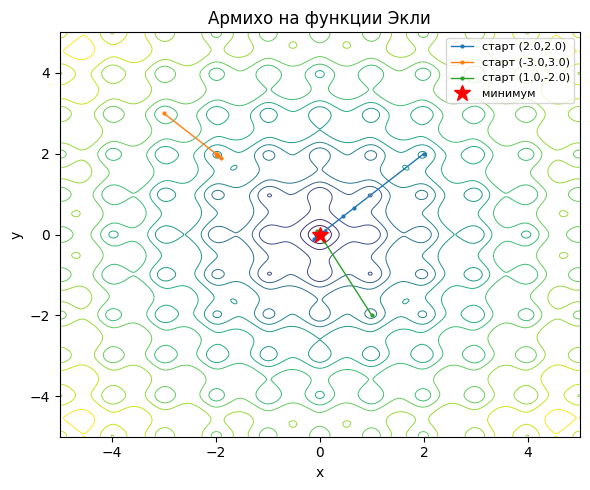

Экли, метод Вольфе
старт       | сошелся | итераций | вызовы f | вызовы grad | найдено                 
------------+---------+----------+----------+-------------+-------------------------
(2.0, 2.0)  | нет     | 100000   | 5199952  | 100051      | (-8.882e-16, -8.882e-16)
(-3.0, 3.0) | нет     | 100000   | 5198829  | 100030      | (-1.974, 1.974)         
(1.0, -2.0) | да      | 1        | 53       | 65          | (0, 0)                  



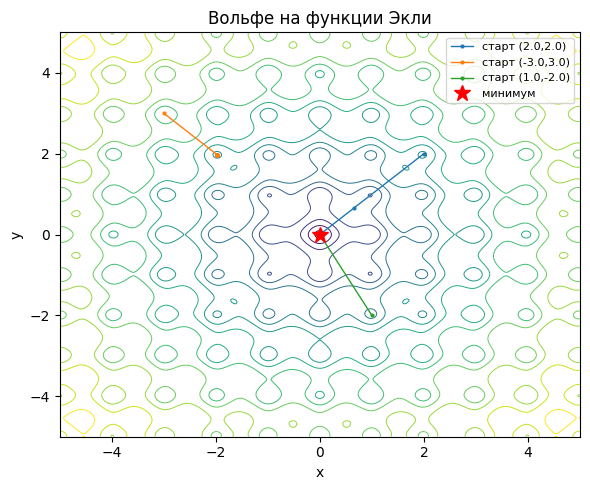

Химмельблау, метод Армихо
старт        | сошелся | итераций | вызовы f | вызовы grad | найдено         
-------------+---------+----------+----------+-------------+-----------------
(0.0, 0.0)   | да      | 30       | 228      | 31          | (3, 2)          
(-2.0, 3.0)  | да      | 17       | 135      | 18          | (-2.805, 3.131) 
(3.0, -2.0)  | да      | 51       | 408      | 52          | (3.584, -1.848) 
(-4.0, -4.0) | да      | 18       | 152      | 19          | (-3.779, -3.283)



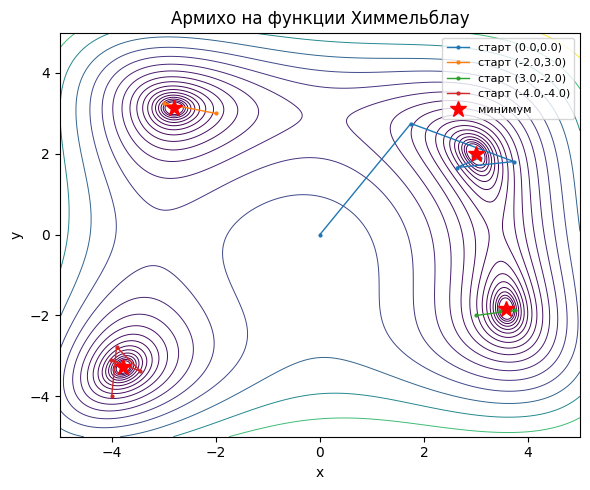

Химмельблау, метод Вольфе
старт        | сошелся | итераций | вызовы f | вызовы grad | найдено         
-------------+---------+----------+----------+-------------+-----------------
(0.0, 0.0)   | да      | 28       | 213      | 61          | (3, 2)          
(-2.0, 3.0)  | да      | 17       | 135      | 35          | (-2.805, 3.131) 
(3.0, -2.0)  | да      | 51       | 408      | 103         | (3.584, -1.848) 
(-4.0, -4.0) | да      | 17       | 144      | 37          | (-3.779, -3.283)



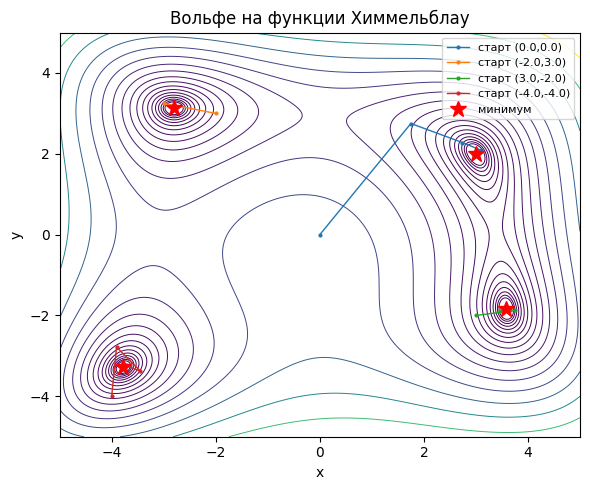

In [9]:
methods = [("Армихо", gd_armijo), ("Вольфе", gd_wolfe)]
for key, name, f, grad in [
    ("rosen", "Розенброка", rosenbrock, grad_rosenbrock),
    ("ackley", "Экли", ackley, grad_ackley),
    ("himmel", "Химмельблау", himmelblau, grad_himmelblau)]:
    for mname, method in methods:
        rows = []; runs = []
        for x0 in STARTS[key]:
            r = run(method, f, grad, x0, eps=EPS)
            xf = r["x"]
            rows.append([f"({x0[0]}, {x0[1]})", "да" if r["converged"] else "нет",
                         r["iters"], r["nf"], r["ng"], f"({fnum(xf[0])}, {fnum(xf[1])})"])
            runs.append((f"старт ({x0[0]},{x0[1]})", r["traj"]))
        print_table(f"{name}, метод {mname}",
                    ["старт", "сошелся", "итераций", "вызовы f", "вызовы grad", "найдено"], rows)
        print()
        show_traj(f"{mname} на функции {name}", f, key, runs)

## Пункт 6

Наискорейший спуск. То же, что в пунктах 4-5: на квадратичных - зависимость от точности, на сложных - запуски из разных стартов с траекториями.

Наискорейший спуск, f (k=2)
eps    | итераций | вызовы f | вызовы grad
-------+----------+----------+------------
0.1    | 5        | 215      | 6          
0.01   | 6        | 258      | 7          
0.001  | 8        | 344      | 9          
0.0001 | 10       | 430      | 11         
1e-05  | 12       | 516      | 13         
1e-06  | 13       | 559      | 14         
1e-07  | 15       | 645      | 16         
1e-08  | 17       | 731      | 18         



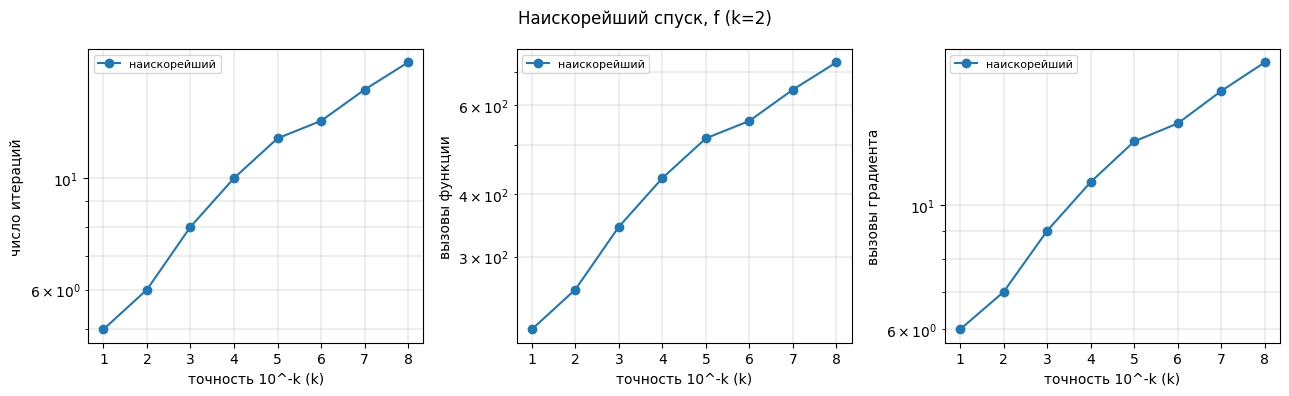

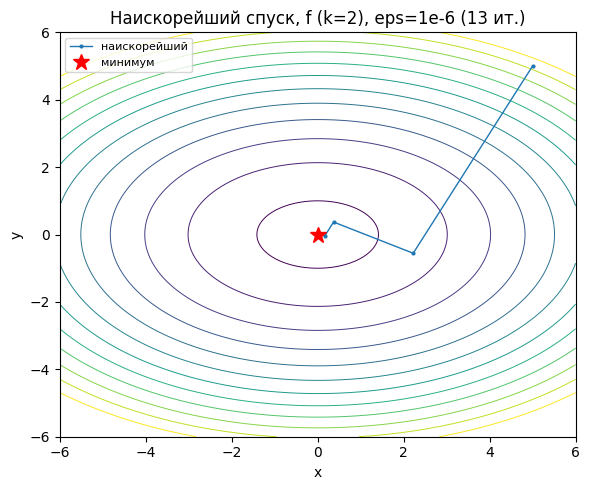

Наискорейший спуск, g (k=100)
eps    | итераций | вызовы f | вызовы grad
-------+----------+----------+------------
0.1    | 3        | 129      | 4          
0.01   | 5        | 215      | 6          
0.001  | 5        | 215      | 6          
0.0001 | 7        | 301      | 8          
1e-05  | 7        | 301      | 8          
1e-06  | 9        | 387      | 10         
1e-07  | 9        | 387      | 10         
1e-08  | 11       | 473      | 12         



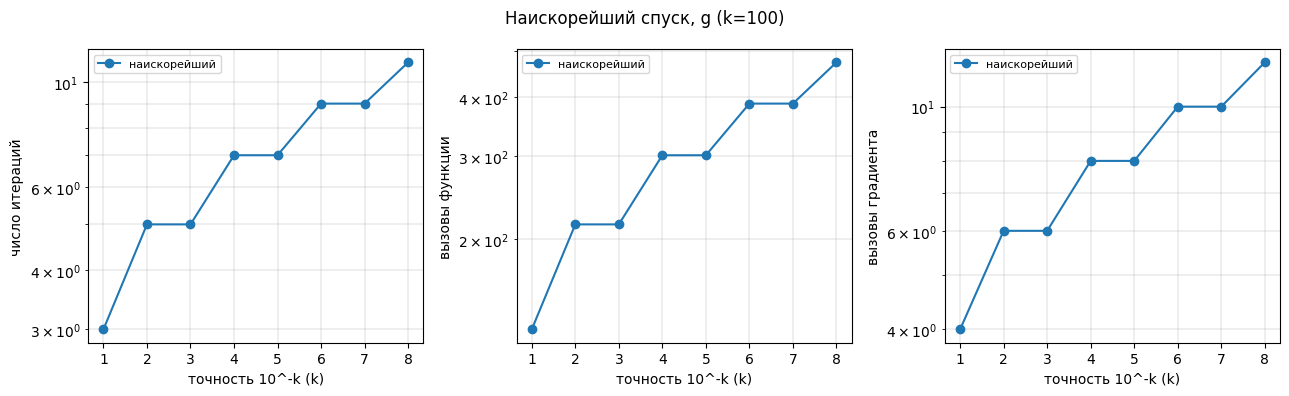

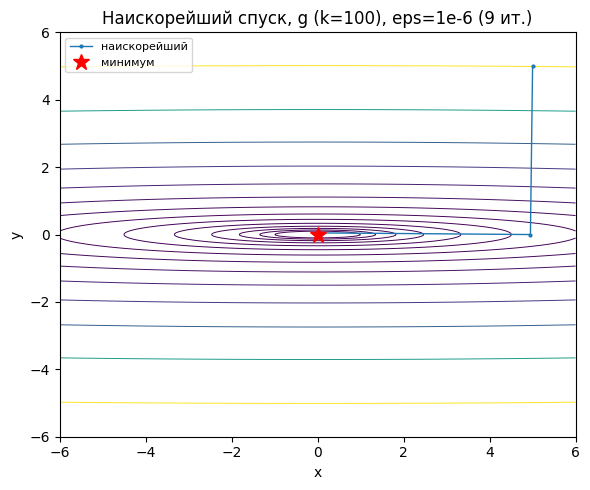

Наискорейший спуск, Розенброка
старт       | сошелся | итераций | вызовы f | вызовы grad | найдено
------------+---------+----------+----------+-------------+--------
(-1.2, 1.0) | да      | 24373    | 1048039  | 24374       | (1, 1) 
(0.0, 2.0)  | да      | 13764    | 591852   | 13765       | (1, 1) 
(2.0, 2.0)  | да      | 3961     | 170325   | 3962        | (1, 1) 



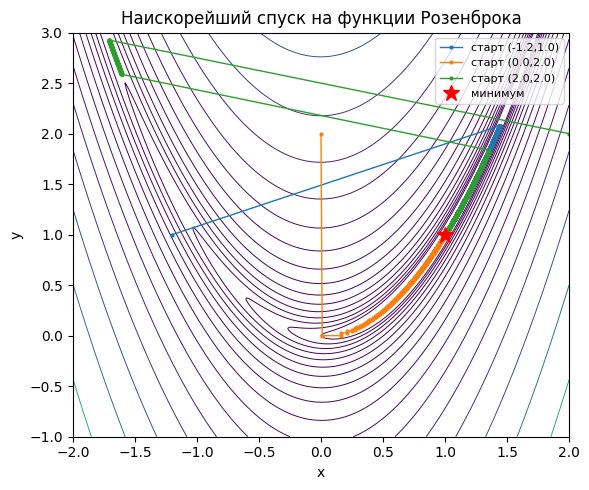

Наискорейший спуск, Экли
старт       | сошелся | итераций | вызовы f | вызовы grad | найдено                
------------+---------+----------+----------+-------------+------------------------
(2.0, 2.0)  | нет     | 100000   | 4300002  | 100000      | (6.549e-09, 6.549e-09) 
(-3.0, 3.0) | нет     | 100000   | 4300004  | 100000      | (-4.765e-09, 4.765e-09)
(1.0, -2.0) | нет     | 100000   | 4300002  | 100000      | (-3.665e-09, 7.331e-09)



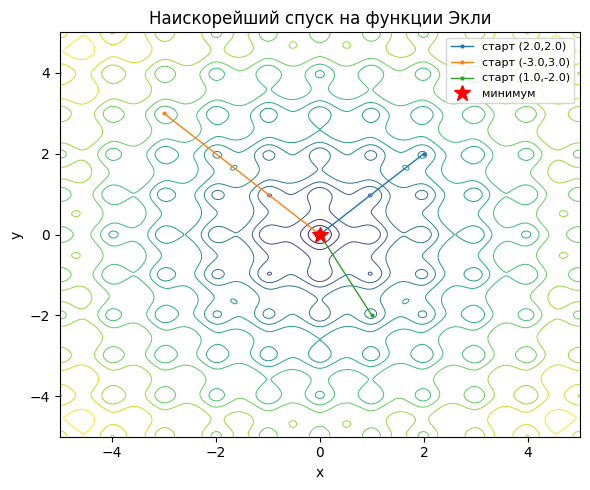

Наискорейший спуск, Химмельблау
старт        | сошелся | итераций | вызовы f | вызовы grad | найдено        
-------------+---------+----------+----------+-------------+----------------
(0.0, 0.0)   | да      | 29       | 1247     | 30          | (3, 2)         
(-2.0, 3.0)  | да      | 8        | 344      | 9           | (-2.805, 3.131)
(3.0, -2.0)  | да      | 10       | 430      | 11          | (3.584, -1.848)
(-4.0, -4.0) | да      | 29       | 1247     | 30          | (3, 2)         



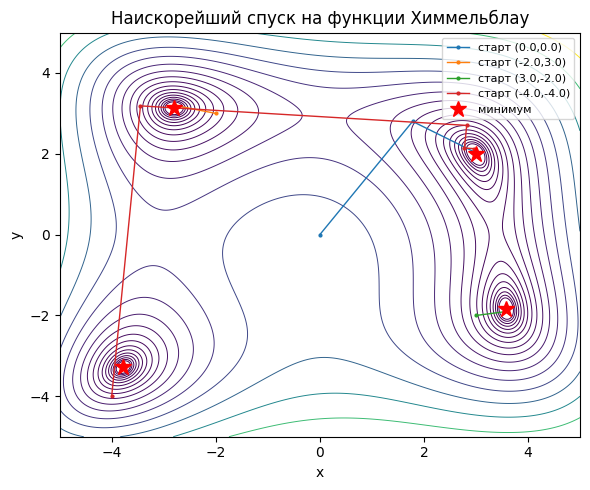

In [10]:
eps_list = [10.0 ** (-k) for k in range(1, 9)]
for key, name, f, grad, x0 in [
    ("f", "f (k=2)", f_quad_good, grad_quad_good, (5., 5.)),
    ("g", "g (k=100)", g_quad_bad, grad_quad_bad, (5., 5.))]:
    rows = []; its = []; nfs = []; ngs = []
    for e in eps_list:
        r = run(gd_steepest, f, grad, x0, eps=e)
        rows.append([fnum(e), r["iters"], r["nf"], r["ng"]])
        its.append(r["iters"]); nfs.append(r["nf"]); ngs.append(r["ng"])
    print_table(f"Наискорейший спуск, {name}",
                ["eps", "итераций", "вызовы f", "вызовы grad"], rows)
    print()
    show_metrics(f"Наискорейший спуск, {name}", eps_list, [("наискорейший", its, nfs, ngs)])
    r = run(gd_steepest, f, grad, x0, eps=1e-6)
    show_traj(f"Наискорейший спуск, {name}, eps=1e-6 ({r['iters']} ит.)",
              f, key, [("наискорейший", r["traj"])])

for key, name, f, grad in [
    ("rosen", "Розенброка", rosenbrock, grad_rosenbrock),
    ("ackley", "Экли", ackley, grad_ackley),
    ("himmel", "Химмельблау", himmelblau, grad_himmelblau)]:
    rows = []; runs = []
    for x0 in STARTS[key]:
        r = run(gd_steepest, f, grad, x0, eps=EPS)
        xf = r["x"]
        rows.append([f"({x0[0]}, {x0[1]})", "да" if r["converged"] else "нет",
                     r["iters"], r["nf"], r["ng"], f"({fnum(xf[0])}, {fnum(xf[1])})"])
        runs.append((f"старт ({x0[0]},{x0[1]})", r["traj"]))
    print_table(f"Наискорейший спуск, {name}",
                ["старт", "сошелся", "итераций", "вызовы f", "вызовы grad", "найдено"], rows)
    print()
    show_traj(f"Наискорейший спуск на функции {name}", f, key, runs)

## Выводы

1. **Постоянный шаг** - самый дешевый (только градиент), но требует подбора шага: есть четкий оптимум, чуть больше - расходимость, чуть меньше - много итераций. На сложных функциях большой шаг почти всегда расходится.
2. **Обусловленность решает все.** Хорошо обусловленная функция (κ=2) - ~20 итераций, плохо обусловленная (κ=100) - ~1000, с характерным зигзагом.
3. **Армихо** избавляет от ручного подбора шага и устойчиво сходится.
4. **Вольфе** дает почти то же число итераций, что и Армихо, но вдвое больше вызовов градиента (проверяет производную). Преимущество проявляется в более сложных методах.
5. **Наискорейший спуск** - наименьшее число итераций, но наибольшее число вызовов функции (одномерный поиск). Это компромисс "скорость по итерациям ↔ стоимость итерации".
6. **Сложные функции**: Розенброка решается, но медленно (овраг); Химмельблау сходится в разные минимумы; Экли многоэкстремальна и негладкая в (0,0), поэтому критерий по норме градиента в глобальном минимуме не срабатывает.